# Polarization data overview

This notebook loads synthetic polarization datasets at 50 C, 60 C, and 70 C, groups each record by pressure level, and then reuses shared plotting helpers for the comparison figures.

The helper cells below keep file lookup, aggregation, and plotting logic in one place so the analysis cells stay short and easier to rerun.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [18]:
PRESSURES = ("P300", "P400", "P500")

sensor_data_cols = [
    "Time(s)",
    "I_LOAD",
    "P_H2",
    "P_AIR",
    "T_H2O_IN",
    "T_H2O_OUT",
    "T_H2O_MEAN",
    "R",
]

pressure_colors = {"P300": "tab:blue", "P400": "tab:orange", "P500": "tab:green"}
pressure_linestyles = {"P300": "-", "P400": "--", "P500": ":"}
temp_colors = {"T50": "tab:blue", "T60": "tab:orange", "T70": "tab:green"}
temp_linestyles = {"T50": "-", "T60": "--", "T70": ":"}
temp_labels = {"T50": "50 C", "T60": "60 C", "T70": "70 C"}

def find_data_file(filename):
    candidates = [Path.cwd() / filename, Path.cwd() / "data" / "rawdata" / filename]
    for path in candidates:
        if path.exists():
            return path
    return None

def resolve_data_file(filename):
    path = find_data_file(filename)
    if path is None:
        raise FileNotFoundError(f"Could not locate {filename} from {Path.cwd()}")
    return path

def read_optional_excel(filename):
    path = find_data_file(filename)
    if path is None:
        print(f"Skipping {filename}: file not found from {Path.cwd()}")
        return None
    return pd.read_excel(path)

def empty_pressure_map():
    return {pressure: [] for pressure in PRESSURES}

def collapse_aux_frames(frames):
    return (
        pd.concat(frames, ignore_index=True).sort_values("Time(s)").reset_index(drop=True)
        if frames
        else pd.DataFrame(columns=sensor_data_cols)
    )

def load_temperature_dataset(filename, pressure_floor=None):
    pola_data = empty_pressure_map()
    aux_data = empty_pressure_map()
    workbook = pd.read_excel(resolve_data_file(filename), sheet_name=None)

    for sheet_name, record in workbook.items():
        if "REC" not in sheet_name:
            continue

        pressure_value = int(round(record["P_H2"].mean(), -2))
        if pressure_floor is not None and pressure_value < pressure_floor:
            pressure_value = 300

        pressure_key = f"P{pressure_value}"
        if pressure_key not in pola_data:
            continue

        pola_data[pressure_key].append((record["VFC"].mean(), record["I_LOAD"].mean()))
        aux_data[pressure_key].append(record[sensor_data_cols])

    aux_data = {pressure: collapse_aux_frames(frames) for pressure, frames in aux_data.items()}
    return pola_data, aux_data

def curve_frame(points):
    return pd.DataFrame(points, columns=["VFC", "I_LOAD"]).sort_values("I_LOAD")

def finalize_plot(xlabel, ylabel, title, legend_title=None, legend_ncol=1, ylim=None):
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.legend(title=legend_title, ncol=legend_ncol)
    plt.tight_layout()
    plt.show()

def plot_full_polarization_map(polarization_data):
    plt.figure(figsize=(9, 6))
    for temp_label, pola_data in polarization_data.items():
        for pressure, points in sorted(pola_data.items()):
            if not points:
                continue
            df = curve_frame(points)
            plt.plot(
                df["I_LOAD"],
                df["VFC"],
                marker="o",
                linewidth=1.8,
                color=pressure_colors[pressure],
                linestyle=temp_linestyles[temp_label],
                label=f"{temp_labels[temp_label]} - {pressure}",
            )
    finalize_plot(
        "Current (A)",
        "Voltage (V)",
        "Polarization Curves: T50, T60, T70",
        legend_title=r"$S_c = 2.5, S_a = 1.2$",
        legend_ncol=3,
    )

def plot_single_temperature(polarization_data, temp_label):
    plt.figure(figsize=(9, 6))
    for pressure, points in sorted(polarization_data[temp_label].items()):
        if not points:
            continue
        df = curve_frame(points)
        plt.plot(
            df["I_LOAD"],
            df["VFC"],
            marker="o",
            linewidth=1.8,
            color=pressure_colors[pressure],
            linestyle=temp_linestyles[temp_label],
            label=f"{temp_labels[temp_label]} - {pressure}",
        )
    finalize_plot(
        "Current (A)",
        "Voltage (V)",
        f"Polarization Curves: {temp_label}",
        legend_title=r"$S_c = 2.5, S_a = 1.2$",
        legend_ncol=3,
    )

def plot_pressure_slice(polarization_data, pressure):
    plt.figure(figsize=(9, 6))
    for temp_label, pola_data in polarization_data.items():
        points = pola_data.get(pressure, [])
        if not points:
            continue
        df = curve_frame(points)
        plt.plot(
            df["I_LOAD"],
            df["VFC"],
            marker="o",
            linewidth=1.8,
            color=temp_colors[temp_label],
            label=temp_labels[temp_label],
        )
    finalize_plot(
        "Current (A)",
        "Voltage (V)",
        f"Polarization Curves at {pressure[1:]} mbar - Effect of Temperature",
        legend_title=r"$S_c = 2.5,\ S_a = 1.2$",
    )

def plot_aux_metric(auxiliary_data, metric, ylabel, title, ylim=None):
    plt.figure(figsize=(9, 6))
    for pressure in PRESSURES:
        for temp_label in ("T50", "T60", "T70"):
            df = auxiliary_data[temp_label][pressure]
            if df.empty:
                continue
            plt.plot(
                df["I_LOAD"],
                df[metric],
                label=f"{temp_labels[temp_label]} - {pressure}",
                color=temp_colors[temp_label],
                linestyle=pressure_linestyles[pressure],
            )
    finalize_plot(
        "Current (A)",
        ylabel,
        title,
        legend_title=r"$S_c = 2.5, S_a = 1.2$",
        legend_ncol=3,
        ylim=ylim,
    )

def plot_dual_axis_window(dataframe, hygrometry_col, hygrometry_label, start=0, stop=None, current_ylim=None, voltage_ylim=None):
    view = dataframe.iloc[start:stop].reset_index(drop=True)
    fig, axes = plt.subplots(figsize=(16, 5), ncols=2, nrows=1)
    fig.subplots_adjust(wspace=0.35)

    line_current, = axes[0].plot(view["I_LOAD"], color="#be291e", label="Current")
    axes[0].set_ylabel("Current (A)")
    axes[0].set_xlabel("Time (s)")
    if current_ylim is not None:
        axes[0].set_ylim(*current_ylim)

    ax2 = axes[0].twinx()
    ax2.set_ylabel("Voltage (V)")
    line_voltage, = ax2.plot(view["VFC"], color="#168b06", label="Voltage")
    if voltage_ylim is not None:
        ax2.set_ylim(*voltage_ylim)
    axes[0].legend(handles=[line_current, line_voltage], loc="upper right")

    axes[1].plot(view[hygrometry_col], color="#be291e", label=hygrometry_label)
    axes[1].set_ylabel(f"{hygrometry_label} (%)")
    axes[1].set_xlabel("Time (s)")
    axes[1].legend(loc="upper left" if hygrometry_col == "HR_H2_FC" else "upper right")

def plot_filtered_resistance(dataframe, start=0, stop=None, window=11, ylim=None):
    r_filtered = dataframe["R"].iloc[start:stop].rolling(window=window, center=True, min_periods=1).median()
    plt.figure(figsize=(10, 4))
    plt.plot(r_filtered, color="#1f77b4", label=f"R (median filter, window={window})")
    plt.xlabel("Time (s)")
    plt.ylabel("R")
    plt.legend()
    if ylim is not None:
        plt.ylim(*ylim)
    plt.tight_layout()
    plt.show()

In [3]:
temperature_files = {
    "T50": ("SYNTH_T50_N1.xlsx", None),
    "T60": ("SYNTH_T60_N1.xlsx", None),
    "T70": ("SYNTH_T70_N1.xlsx", 380),
}

loaded_data = {
    temp_label: load_temperature_dataset(filename, pressure_floor=pressure_floor)
    for temp_label, (filename, pressure_floor) in temperature_files.items()
}

all_pola_data = {temp_label: data[0] for temp_label, data in loaded_data.items()}
all_aux_data = {temp_label: data[1] for temp_label, data in loaded_data.items()}

pola_data_T50, pola_data_T60, pola_data_T70 = (all_pola_data[temp] for temp in ("T50", "T60", "T70"))
aux_data_T50, aux_data_T60, aux_data_T70 = (all_aux_data[temp] for temp in ("T50", "T60", "T70"))

In [4]:
# Main comparison plots are generated by the helper calls below.

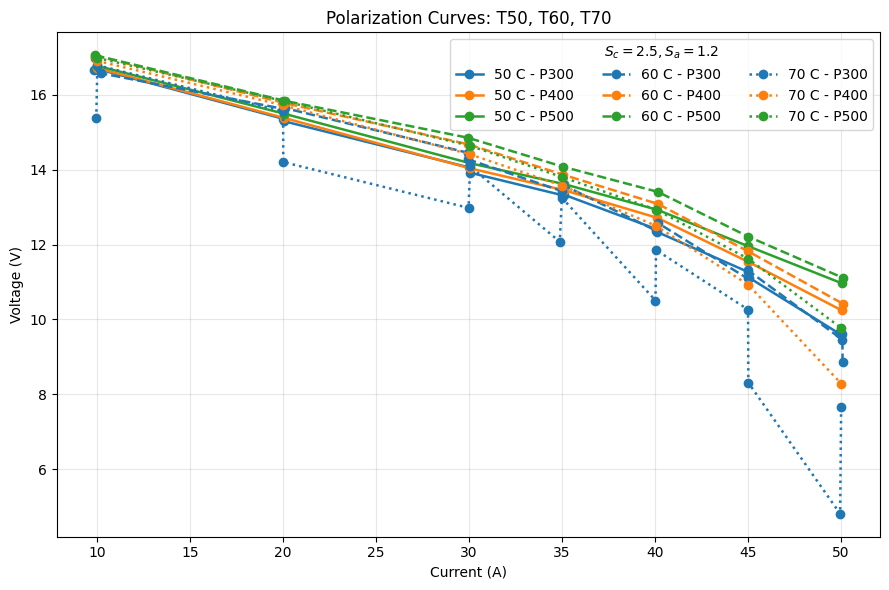

In [19]:
plot_full_polarization_map(all_pola_data)

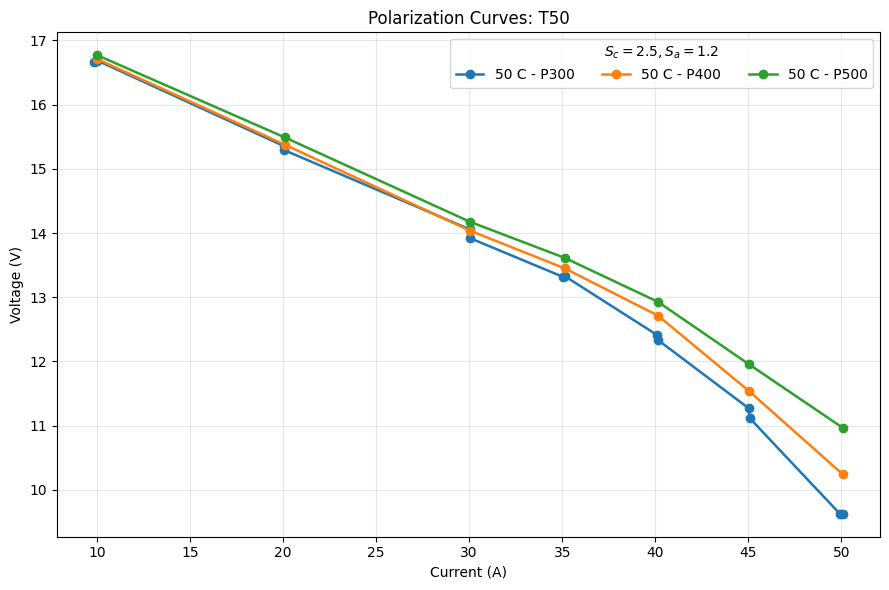

In [20]:
plot_single_temperature(all_pola_data, "T50")

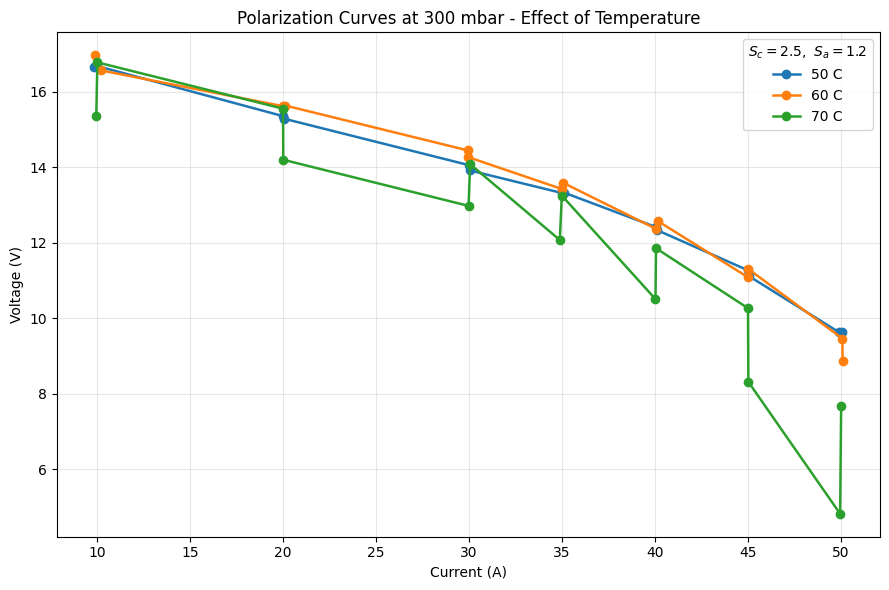

In [21]:
plot_pressure_slice(all_pola_data, "P300")

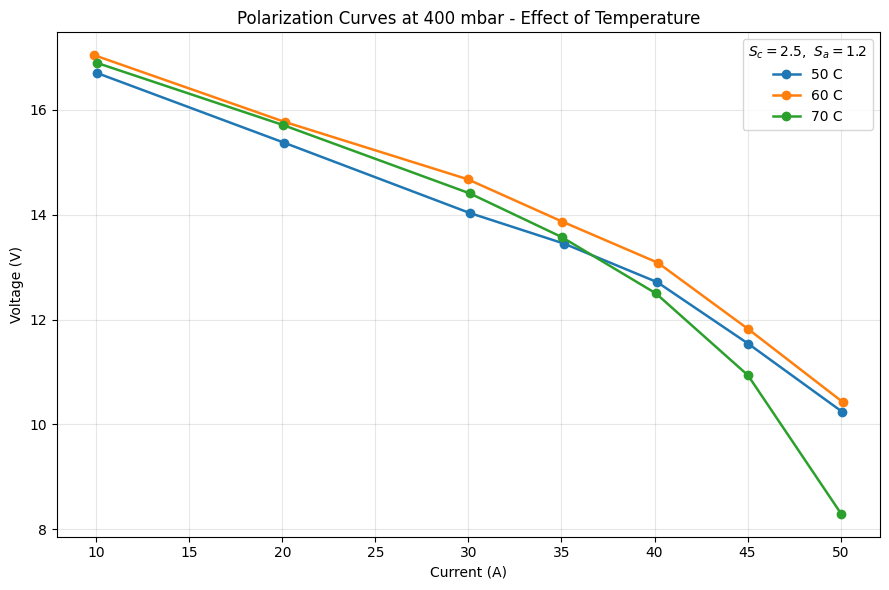

In [22]:
plot_pressure_slice(all_pola_data, "P400")

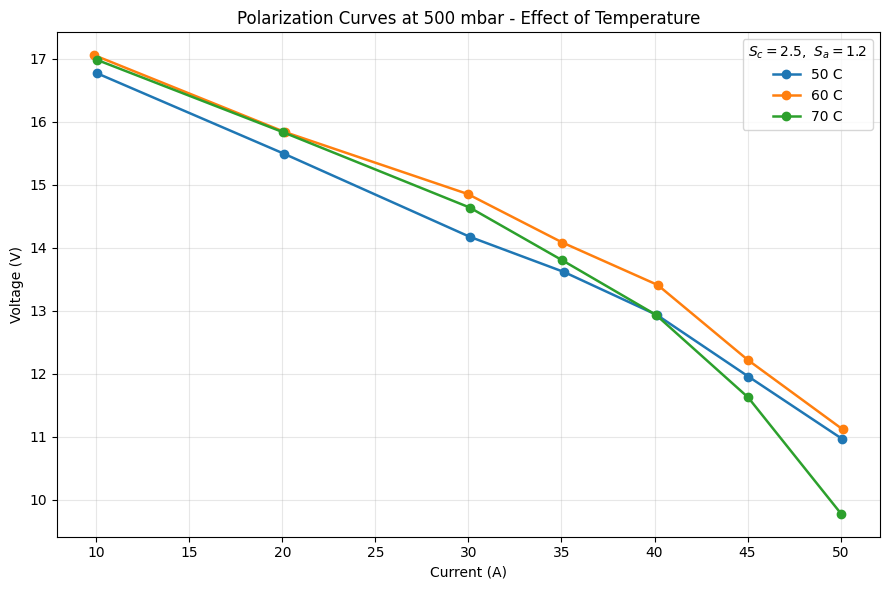

In [23]:
plot_pressure_slice(all_pola_data, "P500")

## Interpretation note

These pressure-sliced plots suggest the higher-temperature cases postpone the onset of flooding. That is consistent with faster water removal, but the mechanism should still be checked against humidity and resistance traces before drawing a firm conclusion.

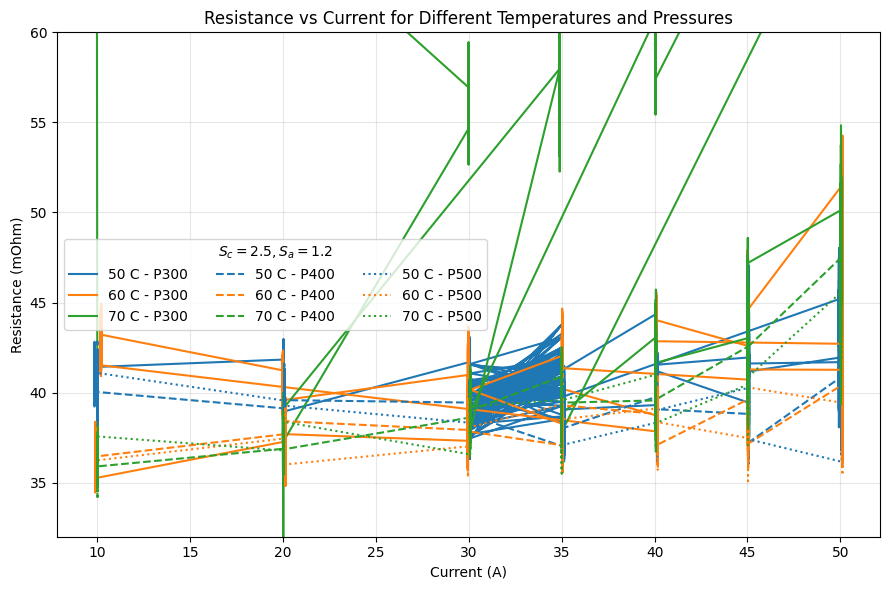

In [24]:
plot_aux_metric(
    all_aux_data,
    "R",
    "Resistance (mOhm)",
    "Resistance vs Current for Different Temperatures and Pressures",
    ylim=(32, 60),
)

In [13]:
# High-current diagnostic window: voltage and air hygrometry during a 50 A hold.
pola_data_HRC = read_optional_excel("REC_03032026_154026.xlsx")
if pola_data_HRC is not None:
    plot_dual_axis_window(
        pola_data_HRC,
        "HR_AIR_FC",
        "Air Hygrometry",
        stop=7000,
        current_ylim=(49, 51),
    )

Skipping REC_03032026_154026.xlsx: file not found from d:\MFC2024\data\rawdata


## Time-series diagnostics

The next cells inspect two targeted operating windows. Each figure pairs current and voltage with a hygrometry trace, then uses a median filter on resistance to make slower trends easier to see.

In [14]:
if pola_data_HRC is not None:
    plot_filtered_resistance(pola_data_HRC, stop=7000, window=11, ylim=(40, 50))
else:
    print("Skipping filtered resistance plot: HRC workbook not available.")

Skipping filtered resistance plot: HRC workbook not available.


In [15]:
# There are several EIS interruptions in this test, visible on the voltage trace.
i_start = 8000
pola_data_Sc = read_optional_excel("REC_24022026_142125.xlsx")
if pola_data_Sc is not None:
    plot_dual_axis_window(
        pola_data_Sc,
        "HR_H2_FC",
        "H2 Hygrometry",
        start=i_start,
        current_ylim=(18, 22),
        voltage_ylim=(15, 17),
    )

Skipping REC_24022026_142125.xlsx: file not found from d:\MFC2024\data\rawdata


In [16]:
if pola_data_Sc is not None:
    plot_filtered_resistance(pola_data_Sc, start=i_start, window=11, ylim=(35, 50))
else:
    print("Skipping filtered resistance plot: Sc workbook not available.")

Skipping filtered resistance plot: Sc workbook not available.
